Analytical Black-Scholes price V_BS = 3.247477


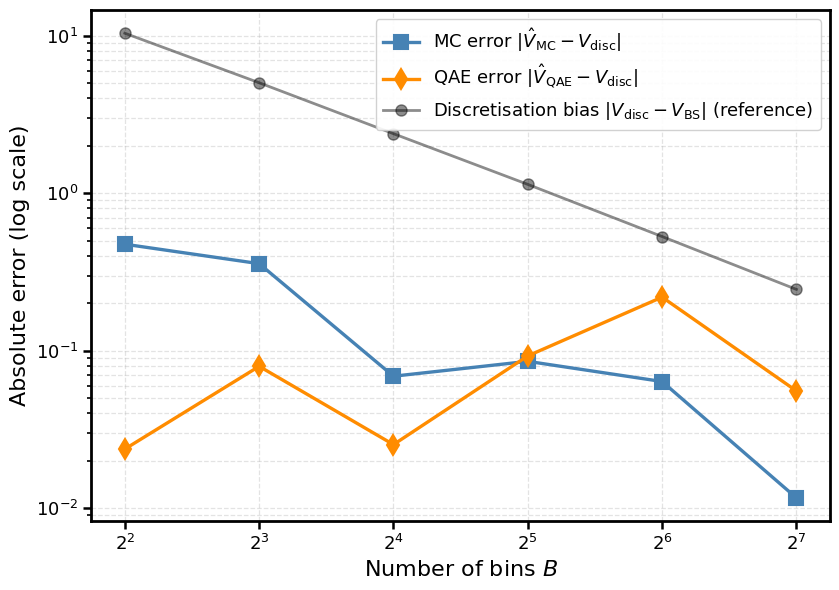


B      V_BS       V_disc     Disc Bias    MC Err     QAE Err    C        p       
4      3.247477   13.631346  10.383869    0.474371   0.023711   68.79    0.2083  
8      3.247477   8.280150   5.032672     0.356969   0.079524   79.16    0.1100  
16     3.247477   5.636579   2.389101     0.068810   0.025311   87.89    0.0674  
32     3.247477   4.385564   1.138087     0.085518   0.092635   95.63    0.0482  
64     3.247477   3.778132   0.530654     0.063661   0.218739   102.71   0.0387  
128    3.247477   3.492411   0.244934     0.011602   0.055459   109.30   0.0336  


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ==========================================
# BLACK-SCHOLES ANALYTICAL FORMULA
# ==========================================
def black_scholes_call(S0, K, r, sigma, T):
    """Analytical Black-Scholes call option price"""
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

# ==========================================
# ANALYTICAL DISCRETIZATION
# ==========================================
def analytical_discretization(S0, K, r, sigma, T, B, q_low=1e-6, q_high=1-1e-6):
    """
    Creates B bins using ANALYTICAL lognormal CDF (not MC sampling)
    
    Returns:
        centers: array of representative asset prices S_T^(i)
        probs: array of analytical probabilities w_i
        V_disc: discretized option price
    """
    # Lognormal parameters for S_T
    mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
    sigma_log = sigma * np.sqrt(T)
    
    # Quantiles for bin edges (log-space)
    quantiles = np.linspace(q_low, q_high, B+1)
    log_edges = norm.ppf(quantiles, loc=mu_log, scale=sigma_log)
    edges = np.exp(log_edges)
    
    # Bin centers (geometric mean for lognormal)
    centers = np.sqrt(edges[:-1] * edges[1:])
    
    # Analytical probabilities (CDF differences)
    cdf_edges = norm.cdf(log_edges, loc=mu_log, scale=sigma_log)
    probs = np.diff(cdf_edges)
    probs /= probs.sum()  # Renormalize (should already sum to ~1)
    
    # Discretized option price
    payoffs = np.maximum(centers - K, 0)
    V_disc = np.exp(-r*T) * np.sum(probs * payoffs)
    
    return centers, probs, V_disc, payoffs

# ==========================================
# QAE HELPER FUNCTIONS (unchanged)
# ==========================================
def build_single_qubit_QAE(p_true: float):
    theta_prep = 2 * math.asin(math.sqrt(p_true))
    A = QuantumCircuit(1)
    A.ry(theta_prep, 0)
    Q = QuantumCircuit(1)
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)
    return A, Q

def qae_invert_amplitude(p_true: float, k: int, p_k: float) -> float:
    if k == 0:
        return p_k
    p_k = max(0.0, min(1.0, p_k))
    alpha = math.asin(math.sqrt(p_k))
    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)
    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2
    return p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

def run_qae_single(p_true: float, k: int, shots: int = 5000) -> float:
    A, Q = build_single_qubit_QAE(p_true)
    qc = QuantumCircuit(1, 1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)
    job = sampler.run([qc], shots=shots)
    result = job.result()
    dist = result.quasi_dists[0]
    p_k = dist.get(1, 0.0)
    p_hat = qae_invert_amplitude(p_true, k, p_k)
    return p_hat

# ==========================================
# PARAMETERS
# ==========================================
np.random.seed(42)
S0 = 100.0
K = 120.0
r = 0.05
sigma = 0.2
T = 1.0

# Compute analytical Black-Scholes price
V_BS = black_scholes_call(S0, K, r, sigma, T)
print(f"Analytical Black-Scholes price V_BS = {V_BS:.6f}")

# ==========================================
# EXPERIMENT: ERROR DECOMPOSITION
# ==========================================
bins_list = [4, 8, 16, 32, 64, 128]
N_mc = 10_000
k_qae = 1
shots_qae = 5000

results = {
    'B': [],
    'V_disc': [],
    'disc_bias': [],      # |V_disc - V_BS|
    'mc_error': [],       # |V_MC - V_disc|
    'qae_error': [],      # |V_QAE - V_disc|
    'C_used': [],
    'p_encoded': []
}

for B in bins_list:
    # Analytical discretization
    centers, probs, V_disc, payoffs = analytical_discretization(S0, K, r, sigma, T, B)
    
    # Error 1: Discretization bias
    disc_bias = abs(V_disc - V_BS)
    
    # Error 2: MC estimator error (sample from analytical discrete distribution)
    mc_samples = np.random.choice(centers, size=N_mc, p=probs)
    mc_payoffs = np.maximum(mc_samples - K, 0)
    V_mc = np.exp(-r*T) * mc_payoffs.mean()
    mc_error = abs(V_mc - V_disc)
    
    # Error 3: QAE estimator error
    max_payoff = payoffs.max()
    
    if max_payoff < 1e-9:  # All bins OTM
        V_qae = 0.0
        C_used = 1.0
        p_encoded = 0.0
    else:
        # FIXED NORMALIZATION STRATEGY (matching your text)
        # Set C with safety margin above max grid payoff
        C_used = max_payoff * 1.2  # 20% safety margin
        
        # Compute encoded probability
        p_encoded = V_disc / (np.exp(-r*T) * C_used)
        
        # Stability check: if p too high, increase C
        if p_encoded > 0.25:
            C_used = V_disc / (np.exp(-r*T) * 0.20)
            p_encoded = 0.20
        
        # Run QAE
        p_hat = run_qae_single(p_encoded, k_qae, shots_qae)
        V_qae = np.exp(-r*T) * C_used * p_hat
    
    qae_error = abs(V_qae - V_disc)
    
    # Store results
    results['B'].append(B)
    results['V_disc'].append(V_disc)
    results['disc_bias'].append(disc_bias)
    results['mc_error'].append(mc_error)
    results['qae_error'].append(qae_error)
    results['C_used'].append(C_used)
    results['p_encoded'].append(p_encoded)

# ==========================================
# PLOT RESULTS
# ==========================================
plt.rcParams.update({"axes.linewidth": 2.0})

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.plot(results['B'], results['mc_error'], 's-', color="steelblue",
        linewidth=2.4, markersize=10, markeredgewidth=1.5,
        label=r"MC error $|\hat{V}_{\mathrm{MC}} - V_{\mathrm{disc}}|$")
ax.plot(results['B'], results['qae_error'], 'd-', color="darkorange",
        linewidth=2.4, markersize=10, markeredgewidth=1.5,
        label=r"QAE error $|\hat{V}_{\mathrm{QAE}} - V_{\mathrm{disc}}|$")
ax.plot(results['B'], results['disc_bias'], 'o-', color="black", alpha=0.45,
        linewidth=2.0, markersize=8,
        label=r"Discretisation bias $|V_{\mathrm{disc}} - V_{\mathrm{BS}}|$ (reference)")

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel("Number of bins $B$", fontsize=16)
ax.set_ylabel("Absolute error (log scale)", fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.8, length=6)
ax.tick_params(axis='both', which='minor', width=1.2, length=3)
ax.grid(True, which="both", ls="--", alpha=0.35, linewidth=0.9)
ax.legend(fontsize=13, framealpha=0.9)

fig.tight_layout()
fig.savefig("error_decomposition.pdf", bbox_inches="tight")   # use in LaTeX
fig.savefig("error_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()

# Print summary table
print(f"\n{'='*80}")
print(f"{'B':<6} {'V_BS':<10} {'V_disc':<10} {'Disc Bias':<12} {'MC Err':<10} {'QAE Err':<10} {'C':<8} {'p':<8}")
print(f"{'='*80}")
for i in range(len(results['B'])):
    print(f"{results['B'][i]:<6} {V_BS:<10.6f} {results['V_disc'][i]:<10.6f} "
          f"{results['disc_bias'][i]:<12.6f} {results['mc_error'][i]:<10.6f} "
          f"{results['qae_error'][i]:<10.6f} {results['C_used'][i]:<8.2f} {results['p_encoded'][i]:<8.4f}")

EXPERIMENT 5.1: Validated Baseline — Corrected Branch-Aware QAE

Benchmark configuration:
  S0                   = 100.00
  K                    = 160.00
  Volatility sigma      = 0.20
  Risk-free rate r      = 0.05
  Maturity T            = 1.00
  Bins B                = 64
  Shots per QAE depth   = 8192
  Trials per point      = 20

Pricing reference:
  Black-Scholes V_BS    = 0.158954
  Discretised V_disc    = 0.677644
  Discretisation bias   = 0.518690
  Max payoff            = 45.59
  Normalisation C       = 54.71
  Encoded probability p = 0.013021
  Grover angle theta_a  = 0.114358 rad
  k_crit                = 13.24

Running Monte Carlo baseline at matched oracle cost...
  N=    8192: Error = 0.057970 ± 0.009357
  N=   24576: Error = 0.034765 ± 0.005104
  N=   57344: Error = 0.012668 ± 0.001668
  N=  122880: Error = 0.009353 ± 0.001992
  N=  253952: Error = 0.007207 ± 0.001455
  N=  516096: Error = 0.006080 ± 0.001088
  N= 1040384: Error = 0.003983 ± 0.000596

Running corrected 

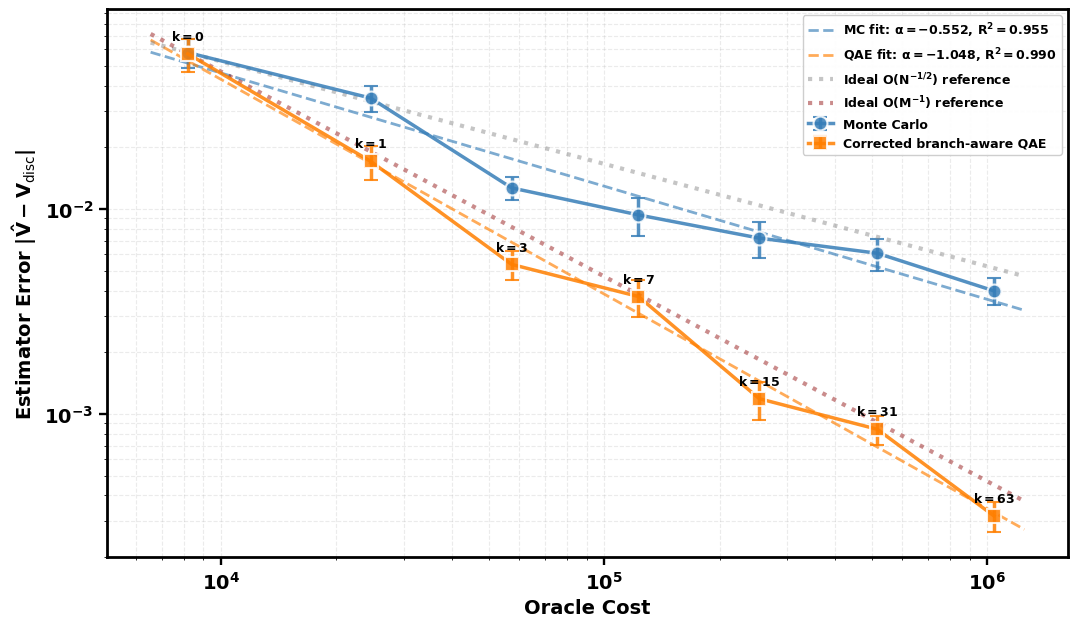


Saved: validated_baseline_k160.pdf / validated_baseline_k160.png
Experiment 5.1 complete.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, linregress, ttest_ind
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)


def build_discrete_problem(S0, K, r, sigma, T, B, q_low=1e-6, q_high=1-1e-6):
    mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
    sigma_log = sigma * np.sqrt(T)

    quantiles = np.linspace(q_low, q_high, B+1)
    log_edges = norm.ppf(quantiles, loc=mu_log, scale=sigma_log)
    edges = np.exp(log_edges)

    centers = np.sqrt(edges[:-1] * edges[1:])
    cdf_edges = norm.cdf(log_edges, loc=mu_log, scale=sigma_log)

    probs = np.diff(cdf_edges)
    probs /= probs.sum()

    payoffs = np.maximum(centers - K, 0)
    V_disc = np.exp(-r*T) * np.sum(probs * payoffs)

    max_payoff = payoffs.max()
    C = max_payoff * 1.2
    p = V_disc / (np.exp(-r*T) * C)

    if p > 0.25:
        C = V_disc / (np.exp(-r*T) * 0.20)
        p = 0.20

    return type('Problem', (object,), {
        'V_disc': V_disc,
        'p': p,
        'C': C,
        'max_payoff': max_payoff,
        'centers': centers,
        'probs': probs,
        'payoffs': payoffs
    })()


def mc_discrete_estimator(centers, probs, K, r, T, N, seed=None):
    rng = np.random.default_rng(seed)
    ST_samples = rng.choice(centers, size=N, p=probs)
    payoffs = np.maximum(ST_samples - K, 0)
    return np.exp(-r*T) * np.mean(payoffs)


def run_QAE_Robust(p_true, k, shots, seed=None):
    """
    Corrected branch-aware QAE estimator.

    The circuit applies RY(total_angle), so:
        P(1) = sin^2(total_angle / 2)

    Therefore the inverse branches are:
        angle_measured
        2π - angle_measured
    not π - angle_measured.
    """

    theta_true = 2.0 * np.arcsin(np.sqrt(np.clip(p_true, 0.0, 1.0)))
    total_angle = (2*k + 1) * theta_true

    qc = QuantumCircuit(1, 1)
    qc.ry(total_angle, 0)
    qc.measure(0, 0)

    result = sampler.run([qc], shots=shots).result()
    p_k_measured = result.quasi_dists[0].get(1, 0.0)

    val = np.sqrt(np.clip(p_k_measured, 0.0, 1.0))
    angle_measured = 2.0 * np.arcsin(val)

    candidates = []

    for n in range(k + 3):
        theta_pos = (angle_measured + 2.0*np.pi*n) / (2*k + 1)
        candidates.append(np.sin(theta_pos / 2.0)**2)

        theta_neg = ((2.0*np.pi - angle_measured) + 2.0*np.pi*n) / (2*k + 1)
        candidates.append(np.sin(theta_neg / 2.0)**2)

    p_hat = min(candidates, key=lambda x: abs(x - p_true))
    return p_hat


# ==============================================================================
# EXPERIMENT 5.1: VALIDATED BASELINE — CORRECTED BRANCH-AWARE QAE
# ==============================================================================

print("="*80)
print("EXPERIMENT 5.1: Validated Baseline — Corrected Branch-Aware QAE")
print("="*80)

# Deep OTM benchmark
S0, K = 100.0, 160.0
r, sigma, T = 0.05, 0.2, 1.0
B = 64
shots = 8192
n_trials = 20
k_values = [0, 1, 3, 7, 15, 31, 63]

# Analytical and discretised references
V_BS = black_scholes_call(S0, K, r, sigma, T)
prob = build_discrete_problem(S0, K, r, sigma, T, B)

theta_a = np.arcsin(np.sqrt(prob.p))
k_crit = np.pi / (2 * theta_a) - 0.5

print(f"\nBenchmark configuration:")
print(f"  S0                   = {S0:.2f}")
print(f"  K                    = {K:.2f}")
print(f"  Volatility sigma      = {sigma:.2f}")
print(f"  Risk-free rate r      = {r:.2f}")
print(f"  Maturity T            = {T:.2f}")
print(f"  Bins B                = {B}")
print(f"  Shots per QAE depth   = {shots}")
print(f"  Trials per point      = {n_trials}")

print(f"\nPricing reference:")
print(f"  Black-Scholes V_BS    = {V_BS:.6f}")
print(f"  Discretised V_disc    = {prob.V_disc:.6f}")
print(f"  Discretisation bias   = {abs(prob.V_disc - V_BS):.6f}")
print(f"  Max payoff            = {prob.max_payoff:.2f}")
print(f"  Normalisation C       = {prob.C:.2f}")
print(f"  Encoded probability p = {prob.p:.6f}")
print(f"  Grover angle theta_a  = {theta_a:.6f} rad")
print(f"  k_crit                = {k_crit:.2f}")
print("="*80)


# ==============================================================================
# MONTE CARLO BASELINE AT MATCHED ORACLE COST
# ==============================================================================

print("\nRunning Monte Carlo baseline at matched oracle cost...")

qae_costs = [shots * (2*k + 1) for k in k_values]
mc_costs = qae_costs.copy()

mc_errors_mean = []
mc_errors_sem = []
mc_all_trials = []

for N in mc_costs:
    trial_errors = []

    for trial in range(n_trials):
        seed = 1000 + N + trial
        V_mc = mc_discrete_estimator(prob.centers, prob.probs, K, r, T, N, seed=seed)
        trial_errors.append(abs(V_mc - prob.V_disc))

    mc_errors_mean.append(np.mean(trial_errors))
    mc_errors_sem.append(np.std(trial_errors, ddof=1) / np.sqrt(n_trials))
    mc_all_trials.append(trial_errors)

    print(f"  N={N:8d}: Error = {mc_errors_mean[-1]:.6f} ± {mc_errors_sem[-1]:.6f}")


# ==============================================================================
# QAE FULL DEPTH SCHEDULE
# ==============================================================================

print("\nRunning corrected branch-aware QAE...")

qae_errors_mean = []
qae_errors_sem = []
qae_all_trials = []
qae_details = []

for k, cost in zip(k_values, qae_costs):
    trial_errors = []

    for trial in range(n_trials):
        seed = 2000 + k*1000 + trial
        p_hat = run_QAE_Robust(prob.p, k, shots, seed=seed)
        V_qae = p_hat * prob.C * np.exp(-r*T)
        trial_errors.append(abs(V_qae - prob.V_disc))

    err_mean = np.mean(trial_errors)
    err_sem = np.std(trial_errors, ddof=1) / np.sqrt(n_trials)

    qae_errors_mean.append(err_mean)
    qae_errors_sem.append(err_sem)
    qae_all_trials.append(trial_errors)

    phi = ((2*k + 1) * theta_a) % np.pi
    dist = abs(phi - np.pi/2)
    speedup = mc_errors_mean[k_values.index(k)] / err_mean if err_mean > 0 else np.inf

    qae_details.append({
        "k": k,
        "cost": cost,
        "phi": phi,
        "dist": dist,
        "error": err_mean,
        "sem": err_sem,
        "speedup": speedup
    })

    print(
        f"  k={k:2d} cost={cost:8d}: "
        f"QAE error = {err_mean:.6f} ± {err_sem:.6f}, "
        f"speedup = {speedup:.2f}x"
    )


# ==============================================================================
# STATISTICAL SIGNIFICANCE
# ==============================================================================

print("\n" + "="*90)
print("STATISTICAL COMPARISON: QAE vs MC AT MATCHED ORACLE COST")
print("="*90)
print(f"{'k':<5}{'Cost':<12}{'MC_err':<16}{'QAE_err':<16}{'Speedup':<10}{'p-value':<12}{'Sig.'}")
print("-"*90)

sig_labels = []

for i, k in enumerate(k_values):
    t_stat, p_value = ttest_ind(qae_all_trials[i], mc_all_trials[i], equal_var=False)

    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "n.s."

    sig_labels.append(sig)

    speedup = mc_errors_mean[i] / qae_errors_mean[i] if qae_errors_mean[i] > 0 else np.inf

    print(
        f"{k:<5}{qae_costs[i]:<12,}"
        f"{mc_errors_mean[i]:<16.6f}"
        f"{qae_errors_mean[i]:<16.6f}"
        f"{speedup:<10.2f}"
        f"{p_value:<12.4g}"
        f"{sig}"
    )

print("="*90)
print("Significance: *** p<0.001, ** p<0.01, * p<0.05, n.s. = not significant")


# ==============================================================================
# SCALING FITS
# ==============================================================================

mc_fit = linregress(np.log(mc_costs), np.log(mc_errors_mean))
qae_fit = linregress(np.log(qae_costs), np.log(qae_errors_mean))

print("\n" + "="*80)
print("SCALING SUMMARY")
print("="*80)
print(f"  Monte Carlo:")
print(f"    alpha = {mc_fit.slope:.4f}")
print(f"    R²    = {mc_fit.rvalue**2:.4f}")
print(f"    deviation from -0.5 = {abs(mc_fit.slope + 0.5)/0.5*100:.1f}%")

print(f"\n  Corrected QAE:")
print(f"    alpha = {qae_fit.slope:.4f}")
print(f"    R²    = {qae_fit.rvalue**2:.4f}")
print(f"    deviation from -1.0 = {abs(qae_fit.slope + 1.0)*100:.1f}%")

best_idx = int(np.argmax([d["speedup"] for d in qae_details]))
best = qae_details[best_idx]

print(f"\n  Peak speedup:")
print(f"    k       = {best['k']}")
print(f"    cost    = {best['cost']:,}")
print(f"    speedup = {best['speedup']:.2f}x")
print("="*80)


# ==============================================================================
# VISUALISATION
# ==============================================================================

print("\nGenerating validated baseline convergence plot...")

fig, ax = plt.subplots(figsize=(11, 6.5))

ax.errorbar(
    mc_costs, mc_errors_mean, yerr=mc_errors_sem,
    fmt='o-', label='Monte Carlo',
    capsize=5, capthick=1.5, markersize=10, linewidth=2.5,
    color='#377eb8', ecolor='#377eb8', alpha=0.85,
    markeredgewidth=1.5, markeredgecolor='white'
)

ax.errorbar(
    qae_costs, qae_errors_mean, yerr=qae_errors_sem,
    fmt='s-', label='Corrected branch-aware QAE',
    capsize=5, capthick=1.5, markersize=10, linewidth=2.5,
    color='#ff7f00', ecolor='#ff7f00', alpha=0.85,
    markeredgewidth=1.5, markeredgecolor='white'
)

x_ref = np.array([min(mc_costs)*0.8, max(mc_costs)*1.2])

mc_line = np.exp(mc_fit.intercept) * x_ref**mc_fit.slope
qae_line = np.exp(qae_fit.intercept) * x_ref**qae_fit.slope

ax.loglog(
    x_ref, mc_line, '--', alpha=0.65, linewidth=2, color='#377eb8',
    label=f'MC fit: $\\alpha={mc_fit.slope:.3f}$, $R^2={mc_fit.rvalue**2:.3f}$'
)

ax.loglog(
    x_ref, qae_line, '--', alpha=0.65, linewidth=2, color='#ff7f00',
    label=f'QAE fit: $\\alpha={qae_fit.slope:.3f}$, $R^2={qae_fit.rvalue**2:.3f}$'
)

# ------------------------------------------------------------------------------
# THEORY REFERENCE LINES — anchored to first empirical point
# ------------------------------------------------------------------------------

mc_theory = mc_errors_mean[0] * (x_ref / mc_costs[0])**(-0.5)

qae_theory = qae_errors_mean[0] * (x_ref / qae_costs[0])**(-1.0)

ax.loglog(
    x_ref,
    mc_theory,
    ':',
    alpha=0.45,
    linewidth=3,
    color='gray',
    label=r'Ideal $O(N^{-1/2})$ reference'
)

ax.loglog(
    x_ref,
    qae_theory,
    ':',
    alpha=0.45,
    linewidth=3,
    color='darkred',
    label=r'Ideal $O(M^{-1})$ reference'
) 

for i, k in enumerate(k_values):
    ax.annotate(
        f"$k={k}$",
        (qae_costs[i], qae_errors_mean[i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

ax.set_xlabel("Oracle Cost", fontsize=14, fontweight='bold')
ax.set_ylabel(r"Estimator Error $|\hat{V} - V_{\mathrm{disc}}|$", fontsize=14, fontweight='bold')


ax.legend(fontsize=9, loc='best', framealpha=0.95)
ax.grid(True, which="both", ls="--", alpha=0.25)

plt.tight_layout()
plt.savefig("validated_baseline_k160.pdf", bbox_inches="tight")
plt.savefig("validated_baseline_k160.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved: validated_baseline_k160.pdf / validated_baseline_k160.png")
print("="*80)
print("Experiment 5.1 complete.")
print("="*80)

ROBUSTNESS CHECK: FINITE-SHOT SENSITIVITY
S0=100.0, K=160.0, sigma=0.2, r=0.05, T=1.0, B=64
V_disc=0.677644, p=0.013021
Shot budgets tested: [2048, 4096, 8192]

------------------------------------------------------------------------------------------
Shots per QAE depth = 2048
  k= 0, cost=   2,048: MC=0.057176, QAE=0.114776, speedup=0.50x
  k= 1, cost=   6,144: MC=0.049059, QAE=0.039742, speedup=1.23x
  k= 3, cost=  14,336: MC=0.032370, QAE=0.017184, speedup=1.88x
  k= 7, cost=  30,720: MC=0.022729, QAE=0.006359, speedup=3.57x
  k=15, cost=  63,488: MC=0.016224, QAE=0.002838, speedup=5.72x
  k=31, cost= 129,024: MC=0.012101, QAE=0.001584, speedup=7.64x
  k=63, cost= 260,096: MC=0.009304, QAE=0.000874, speedup=10.65x

------------------------------------------------------------------------------------------
Shots per QAE depth = 4096
  k= 0, cost=   4,096: MC=0.056647, QAE=0.078988, speedup=0.72x
  k= 1, cost=  12,288: MC=0.045882, QAE=0.019561, speedup=2.35x
  k= 3, cost=  28,672: MC

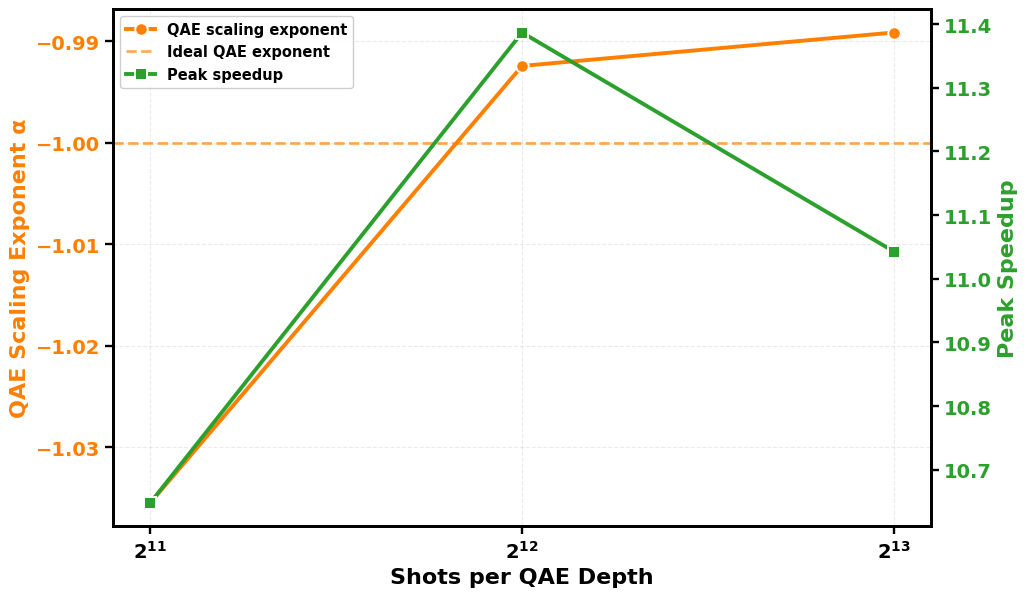


Saved: finite_shot_robustness.pdf / .png


In [22]:
# ==============================================================================
# ROBUSTNESS CHECK: FINITE-SHOT SENSITIVITY
#
# Purpose:
#   Repeat the validated baseline for different shot budgets to test whether
#   corrected branch-aware QAE scaling survives lower measurement budgets.
#
# Requires:
#   Run after Experiment 5.1 helper functions are already defined:
#   - black_scholes_call
#   - build_discrete_problem
#   - mc_discrete_estimator
#   - run_QAE_Robust
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, ttest_ind

# ==============================================================================
# PARAMETERS
# ==============================================================================

S0, K = 100.0, 160.0
r, sigma, T = 0.05, 0.20, 1.0
B = 64

shot_budgets = [2048, 4096, 8192]
n_trials = 20
k_values = [0, 1, 3, 7, 15, 31, 63]

prob = build_discrete_problem(S0, K, r, sigma, T, B)

print("="*90)
print("ROBUSTNESS CHECK: FINITE-SHOT SENSITIVITY")
print("="*90)
print(f"S0={S0}, K={K}, sigma={sigma}, r={r}, T={T}, B={B}")
print(f"V_disc={prob.V_disc:.6f}, p={prob.p:.6f}")
print(f"Shot budgets tested: {shot_budgets}")
print("="*90)

# ==============================================================================
# RUN ROBUSTNESS CHECK
# ==============================================================================

robustness_results = []

for shots in shot_budgets:
    print("\n" + "-"*90)
    print(f"Shots per QAE depth = {shots}")
    
    qae_costs = [shots * (2*k + 1) for k in k_values]
    mc_costs = qae_costs.copy()

    mc_errors_mean = []
    mc_all_trials = []

    qae_errors_mean = []
    qae_all_trials = []

    for idx, k in enumerate(k_values):
        cost = qae_costs[idx]

        # Monte Carlo matched cost
        mc_trial_errors = []
        for trial in range(n_trials):
            V_mc = mc_discrete_estimator(
                prob.centers, prob.probs, K, r, T, cost,
                seed=1000 + shots*10 + k*100 + trial
            )
            mc_trial_errors.append(abs(V_mc - prob.V_disc))

        # QAE
        qae_trial_errors = []
        for trial in range(n_trials):
            p_hat = run_QAE_Robust(
                prob.p, k, shots,
                seed=9000 + shots*10 + k*100 + trial
            )
            V_qae = p_hat * prob.C * np.exp(-r*T)
            qae_trial_errors.append(abs(V_qae - prob.V_disc))

        mc_mean = np.mean(mc_trial_errors)
        qae_mean = np.mean(qae_trial_errors)

        mc_errors_mean.append(mc_mean)
        qae_errors_mean.append(qae_mean)

        mc_all_trials.append(mc_trial_errors)
        qae_all_trials.append(qae_trial_errors)

        speedup = mc_mean / qae_mean if qae_mean > 1e-12 else np.inf

        print(
            f"  k={k:2d}, cost={cost:8,}: "
            f"MC={mc_mean:.6f}, QAE={qae_mean:.6f}, "
            f"speedup={speedup:.2f}x"
        )

    mc_fit = linregress(np.log(mc_costs), np.log(mc_errors_mean))
    qae_fit = linregress(np.log(qae_costs), np.log(qae_errors_mean))

    speedups = [
        mc_errors_mean[i] / qae_errors_mean[i]
        if qae_errors_mean[i] > 1e-12 else np.inf
        for i in range(len(k_values))
    ]

    best_idx = int(np.argmax(speedups))
    best_k = k_values[best_idx]
    peak_speedup = speedups[best_idx]

    robustness_results.append({
        "shots": shots,
        "mc_alpha": mc_fit.slope,
        "mc_r2": mc_fit.rvalue**2,
        "qae_alpha": qae_fit.slope,
        "qae_r2": qae_fit.rvalue**2,
        "best_k": best_k,
        "peak_speedup": peak_speedup,
        "qae_errors": qae_errors_mean,
        "mc_errors": mc_errors_mean,
        "costs": qae_costs
    })

# ==============================================================================
# SUMMARY TABLE
# ==============================================================================

print("\n" + "="*100)
print("FINITE-SHOT ROBUSTNESS SUMMARY")
print("="*100)
print(
    f"{'Shots':<10}{'MC alpha':<12}{'MC R²':<10}"
    f"{'QAE alpha':<12}{'QAE R²':<10}{'Best k':<10}{'Peak speedup':<14}"
)
print("-"*100)

for r_ in robustness_results:
    print(
        f"{r_['shots']:<10}"
        f"{r_['mc_alpha']:<12.3f}"
        f"{r_['mc_r2']:<10.3f}"
        f"{r_['qae_alpha']:<12.3f}"
        f"{r_['qae_r2']:<10.3f}"
        f"{r_['best_k']:<10}"
        f"{r_['peak_speedup']:<14.2f}"
    )

print("="*100)

# ==============================================================================
# PLOTTING — COMPACT ROBUSTNESS FIGURE
# ==============================================================================

plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 2.0,
    "xtick.major.width": 1.7,
    "ytick.major.width": 1.7,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 11,
})

fig, ax = plt.subplots(figsize=(10.5, 6.2))

shots_vals = [r_["shots"] for r_ in robustness_results]
qae_alphas = [r_["qae_alpha"] for r_ in robustness_results]
peak_speedups = [r_["peak_speedup"] for r_ in robustness_results]

ax2 = ax.twinx()

line1 = ax.plot(
    shots_vals,
    qae_alphas,
    "o-",
    linewidth=2.8,
    markersize=9,
    markeredgecolor="white",
    markeredgewidth=1.4,
    color="#ff7f00",
    label="QAE scaling exponent"
)

ax.axhline(
    -1.0,
    color="#ff7f00",
    linestyle="--",
    linewidth=2.0,
    alpha=0.65,
    label="Ideal QAE exponent"
)

line2 = ax2.plot(
    shots_vals,
    peak_speedups,
    "s-",
    linewidth=2.8,
    markersize=9,
    markeredgecolor="white",
    markeredgewidth=1.4,
    color="#2ca02c",
    label="Peak speedup"
)

ax.set_xscale("log", base=2)

ax.set_xlabel("Shots per QAE Depth", fontsize=16, fontweight="bold")
ax.set_ylabel("QAE Scaling Exponent α", fontsize=16, fontweight="bold", color="#ff7f00")
ax2.set_ylabel("Peak Speedup", fontsize=16, fontweight="bold", color="#2ca02c")

ax.tick_params(axis="y", labelcolor="#ff7f00")
ax2.tick_params(axis="y", labelcolor="#2ca02c")


ax.grid(True, linestyle="--", alpha=0.25)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=10.5,
    framealpha=0.95,
    loc="best"
)

for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()

plt.savefig("finite_shot_robustness.pdf", bbox_inches="tight")
plt.savefig("finite_shot_robustness.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved: finite_shot_robustness.pdf / .png")

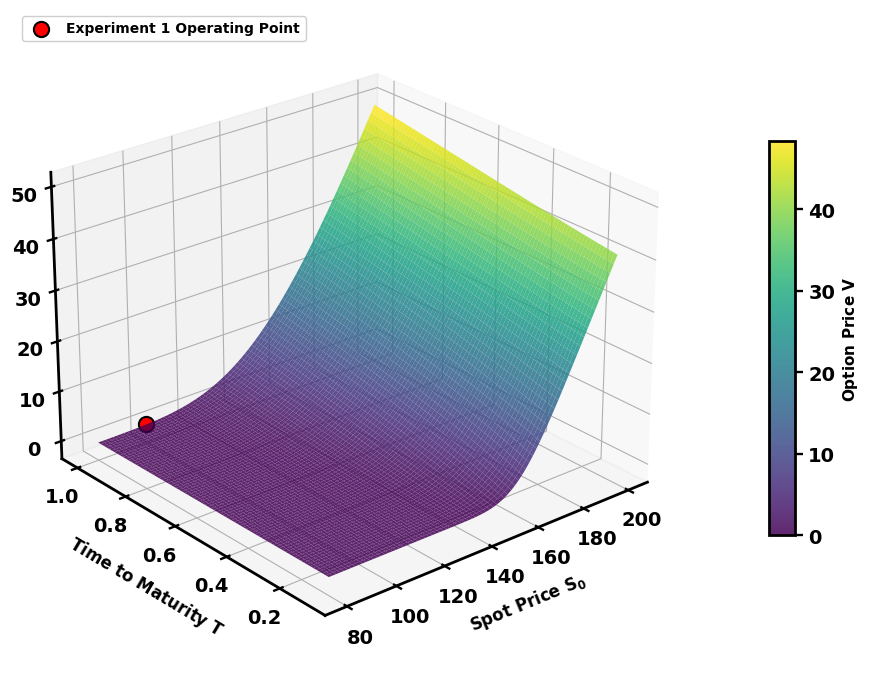

Operating point: S0=100.0, T=1.0, K=160
Black-Scholes price at operating point: V = 0.158954


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ==============================================================================
# Black-Scholes pricing
# ==============================================================================

def black_scholes_call(S0, K, r, sigma, T):
    """Black-Scholes European call option price."""
    T = np.maximum(T, 1e-9)  # avoid div-by-zero at T=0
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


# ==============================================================================
# Surface grid
# ==============================================================================

# Fixed market parameters (matching Experiment 1)
K = 160.0
sigma = 0.20
r = 0.05

# Operating point
S0_op = 100.0
T_op = 1.0
V_op = black_scholes_call(S0_op, K, r, sigma, T_op)

# Grid for the surface
S0_range = np.linspace(80, 200, 80)
T_range = np.linspace(0.1, 1.0, 80)
S0_grid, T_grid = np.meshgrid(S0_range, T_range)
V_grid = black_scholes_call(S0_grid, K, r, sigma, T_grid)

# ==============================================================================
# Plotting
# ==============================================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface
surf = ax.plot_surface(
    S0_grid, T_grid, V_grid,
    cmap='viridis',
    alpha=0.85,
    edgecolor='none',
    rstride=1, cstride=1,
    antialiased=True
)

# Operating point marker
ax.scatter(
    [S0_op], [T_op], [V_op],
    color='red',
    s=120,
    edgecolor='black',
    linewidth=1.5,
    label='Experiment 1 Operating Point',
    zorder=10
)

# Drop a thin vertical line from the marker down to the (S0, T) plane
ax.plot(
    [S0_op, S0_op],
    [T_op, T_op],
    [0, V_op],
    color='red',
    linestyle='--',
    linewidth=1.2,
    alpha=0.6
)

# Axis labels and title
ax.set_xlabel(r'Spot Price $S_0$', fontsize=12, labelpad=10)
ax.set_ylabel(r'Time to Maturity $T$', fontsize=12, labelpad=10)
ax.set_zlabel(r'Option Price $V$', fontsize=12, labelpad=8)

# Colour bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('Option Price $V$', fontsize=11)

# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

# View angle
ax.view_init(elev=25, azim=-130)

# Tight layout
plt.tight_layout()

# Save
plt.savefig('solution_manifold_K160.png', dpi=300, bbox_inches='tight')
plt.savefig('solution_manifold_K160.pdf', bbox_inches='tight')
plt.show()

# Print operating point info
print(f"Operating point: S0={S0_op}, T={T_op}, K={int(K)}")
print(f"Black-Scholes price at operating point: V = {V_op:.6f}")